# Mini Project 10 :- Food Delivery Time Prediction using Machine Learning: End-to-End ML Workflow

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Food_Delivery_Times.csv")

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
# Business Problem :-
# Food delivery companies ko accurate ETA (Estimated Time of Arrival) dikhana hai.
# Example --> Your order will arrive in 32 minutes.

# Project Objective :-
# Food delivery companies ko accurate delivery time predict karne me help karna.

In [5]:
df.shape

(1000, 9)

In [6]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [14]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.870301,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,4.579381,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [8]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# Filling Missing Values

In [10]:
# Weather me missing values fill karna
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

# Traffic Level
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])

# Time Of Day
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])

# Ye columns categorical hain --> inme mode use karenge....sabse zyada repeat hone wali value.

In [11]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day                0
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [12]:
# numerical column --> mean use karenge

df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())

In [13]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [15]:
# Target Variable Analysis -->

# EDA

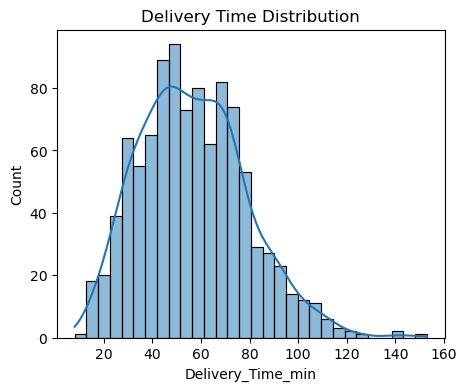

In [25]:
# Delivery Time distribution dekhna

plt.figure(figsize=(5,4))
sns.histplot(df['Delivery_Time_min'],bins=30,kde=True)
plt.title("Delivery Time Distribution")
plt.show()

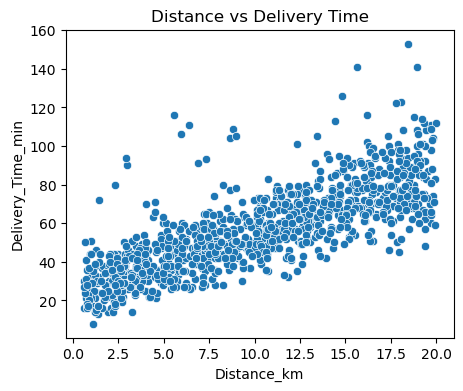

In [18]:
plt.figure(figsize=(5,4))
sns.scatterplot(x='Distance_km',y='Delivery_Time_min',data=df)
plt.title("Distance vs Delivery Time")
plt.show()

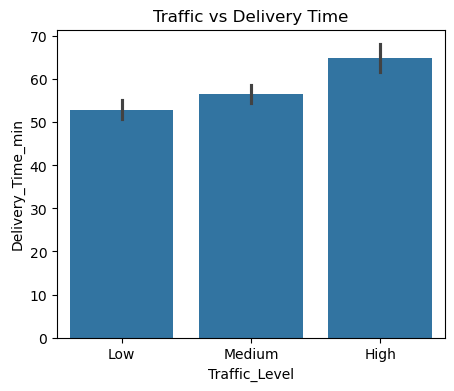

In [23]:
plt.figure(figsize=(5,4))
sns.barplot(x='Traffic_Level',y='Delivery_Time_min',data=df)
plt.title("Traffic vs Delivery Time")
plt.show()

In [26]:
# Order ID remove karna

df.drop('Order_ID',axis=1,inplace=True)

In [27]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


# One-Hot Encoding

In [28]:
# Categorical columns ko numerical banana

df = pd.get_dummies(df,columns=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type'],
                    drop_first=True)

In [29]:
df.head()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,12,1.0,43,False,False,False,True,True,False,False,False,False,False,True
1,16.42,20,2.0,84,False,False,False,False,False,True,True,False,False,False,False
2,9.52,28,1.0,59,True,False,False,False,True,False,False,False,True,False,True
3,7.44,5,1.0,37,False,True,False,False,False,True,False,False,False,False,True
4,19.03,16,5.0,68,False,False,False,False,True,False,False,True,False,False,False


In [30]:
df.columns

Index(['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy',
       'Weather_Windy', 'Traffic_Level_Low', 'Traffic_Level_Medium',
       'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
       'Vehicle_Type_Car', 'Vehicle_Type_Scooter'],
      dtype='object')

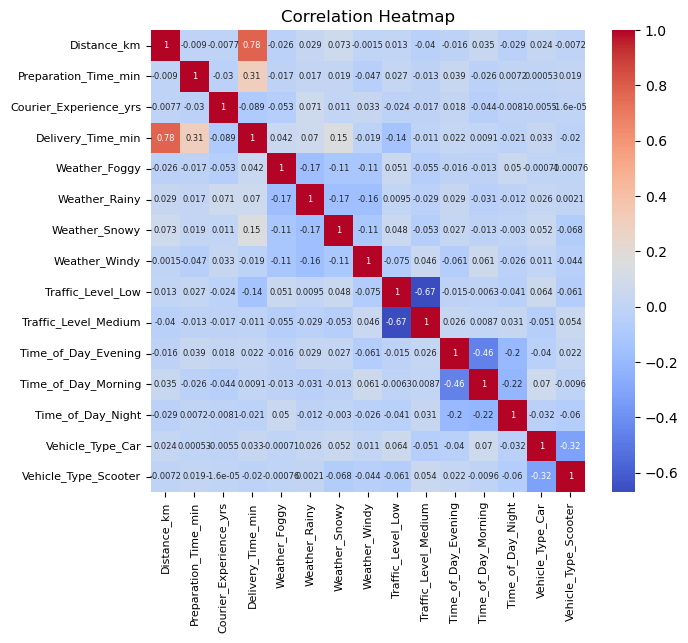

In [35]:
plt.figure(figsize=(7,6))
sns.heatmap(df.corr(),cmap='coolwarm',annot=True,annot_kws={"size":6})
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title("Correlation Heatmap")
plt.show()

# Feature Selection

In [36]:
# Input Features
X = df.drop('Delivery_Time_min',axis=1)

# Target Variable
y = df['Delivery_Time_min']

# Train-Test-Split

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (800, 14)
Testing Shape : (200, 14)


# Linear Regression

In [40]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

# Training
lr_model.fit(X_train,y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# MAE
lr_mae = mean_absolute_error(y_test,lr_pred)

# RMSE
lr_rmse = np.sqrt(
    mean_squared_error(y_test,lr_pred))

# R2 Score
lr_r2 = r2_score(y_test,lr_pred)

print("Linear Regression Results")
print("-------------------------")

print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

Linear Regression Results
-------------------------
MAE : 5.899386793199692
RMSE : 8.823213329620401
R2 Score : 0.8263176966089756


# Random Forest Regressor

In [41]:
from sklearn.ensemble import RandomForestRegressor

In [43]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

# Training
rf_model.fit(X_train,y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

In [44]:
# MAE
rf_mae = mean_absolute_error(y_test,rf_pred)

# RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))

# R2 Score
rf_r2 = r2_score(y_test,rf_pred)

print("Random Forest Results")
print("---------------------")

print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

Random Forest Results
---------------------
MAE : 7.125800000000001
RMSE : 10.2649866049596
R2 Score : 0.7649183206789373


# Business Recommendations 

In [45]:
print("""

BUSINESS RECOMMENDATIONS

1. High traffic routes ko avoid karein.

2. Experienced couriers ko long-distance orders assign karein.

3. Real-time traffic data use karein.

4. Preparation time reduce karne par focus karein.

5. Weather conditions ko ETA prediction me include karein.

6. Model ko monthly retrain karein.

""")



BUSINESS RECOMMENDATIONS

1. High traffic routes ko avoid karein.

2. Experienced couriers ko long-distance orders assign karein.

3. Real-time traffic data use karein.

4. Preparation time reduce karne par focus karein.

5. Weather conditions ko ETA prediction me include karein.

6. Model ko monthly retrain karein.




# Conclusion

In [ ]:
# CONCLUSION :-

# Random Forest Regressor ne Linear Regression se better performance di.

# Model successfully delivery time predict kar sakta hai using:
# Distance
# Weather
# Traffic Level
# Time of Day
# Vehicle Type
# Preparation Time
# Courier Experience

# Is model ko food delivery apps me deploy karke accurate ETA (Estimated Time of Arrival) provide ki ja sakti hai.